# Training DeepLabV3+ for SAR Segmentation

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Keyword 'img_size' unknown")
warnings.filterwarnings("ignore", message="Implicit dimension choice for softmax")
warnings.filterwarnings("ignore", ".*IProgress not found.*")

## Imports

In [2]:
import random
import albumentations as A
from torch.utils.data import DataLoader

import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
import ActivationExamples_SARSeg.examples_utils as utils
from ActivationExamples_SARSeg.examples_utils import *

initialized = False

## Setup

In [3]:
lmdb_path = '../data/BigEarthNet/Encoded-BigEarthNet'
parquet_path = '../data/BigEarthNet/metadata.parquet'

In [4]:
if not initialized:
    train_matches, val_matches, test_matches = match_keys(parquet_path)
    initialized = True

In [5]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
], is_check_shapes=False)

print(f"Train size: {len(train_matches)}, Val size: {len(val_matches)}, Test size: {len(test_matches)}")

train_dataset = SARSegmentationDataset120(lmdb_path, train_matches[:], transform=transform)
val_dataset = SARSegmentationDataset120(lmdb_path, val_matches[:], transform=None)
test_dataset = SARSegmentationDataset120(lmdb_path, test_matches[:], transform=None)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_train_img = len(train_dataset)
num_val_img = len(val_dataset)
num_test_img = len(test_dataset)

steps_per_epoch = num_train_img // batch_size
val_steps_per_epoch = num_val_img // batch_size
print("Steps per epoch: ", steps_per_epoch)
print("Validation steps per epoch: ", val_steps_per_epoch)

Train size: 237871, Val size: 122342, Test size: 119825
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...
Steps per epoch:  14866
Validation steps per epoch:  7646


## Training

In [6]:
import torch.optim as optim

random.seed(42)
want_to_train = True

model = load_base_with_bigearth_pretrained_deeplabv3plus()

# Freeze encoder layers
for param in model.encoder.parameters():
    param.requires_grad = False

# RESUME SETUP (uncomment for 2nd+ run)
# checkpoint_path = "../models/deeplabv3plus120_full_checkpoint_epoch_N.pth"
# optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
# state = load_training_checkpoint(checkpoint_path, model, optimizer, scheduler)
# resume_kwargs = dict(optimizer=optimizer, scheduler=scheduler,
#                      best_val_loss=state["best_val_loss"],
#                      patience_counter=state["patience_counter"])

resume_kwargs = {}

if want_to_train:
    model, optimizer = training(
        model=model,
        epoch_start=1,
        epoch_end=5,
        train_loader=train_loader,
        val_loader=val_loader,
        num_classes=20,
        lr=1e-4,
        model_name="deeplabv3plus120_full",
        **resume_kwargs,
    )
else:
    print("Not training")

Epoch 1/5: 100%|██████████| 14867/14867 [23:03<00:00, 10.75batch/s, f1=0.517, iou=0.353, loss=4.34, lr=0.0001]


Epoch 1, Train Loss: 4.3409, IoU: 0.3533, F1: 0.5167


Validation: 100%|██████████| 7647/7647 [07:44<00:00, 16.46batch/s, f1=0.537, iou=0.404, loss=3.94, lr=0.0001]


Epoch 1, Val Loss: 3.9362, IoU: 0.4037, F1: 0.5373
 Learning rate after epoch 1: 0.0001


Epoch 2/5: 100%|██████████| 14867/14867 [22:21<00:00, 11.08batch/s, f1=0.541, iou=0.375, loss=4.33, lr=0.0001]


...

Epoch 4, Val Loss: 3.9085, IoU: 0.4486, F1: 0.5887
 Learning rate after epoch 4: 0.0001


Epoch 5/5: 100%|██████████| 14867/14867 [26:57<00:00,  9.19batch/s, f1=0.604, iou=0.437, loss=4.29, lr=0.0001]


Epoch 5, Train Loss: 4.2883, IoU: 0.4370, F1: 0.6038


Validation: 100%|██████████| 7647/7647 [07:38<00:00, 16.69batch/s, f1=0.554, iou=0.416, loss=3.93, lr=0.0001]


Epoch 5, Val Loss: 3.9273, IoU: 0.4160, F1: 0.5544
 Learning rate after epoch 5: 0.0001
Last used learning rate: 0.0001


In [7]:
# RESUME SETUP (uncomment for 2nd+ run)
checkpoint_path = "../models/deeplabv3plus120_full_checkpoint_epoch_5.pth"
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
state = load_training_checkpoint(checkpoint_path, model, optimizer, scheduler)
resume_kwargs = dict(optimizer=optimizer, scheduler=scheduler,
                     best_val_loss=state["best_val_loss"],
                     patience_counter=state["patience_counter"])

if want_to_train:
    model, optimizer = training(
        model=model,
        epoch_start=6,
        epoch_end=10,
        train_loader=train_loader,
        val_loader=val_loader,
        num_classes=20,
        lr=1e-4,
        model_name="deeplabv3plus120_full",
        **resume_kwargs,
    )
else:
    print("Not training")

Epoch 6/10: 100%|██████████| 14867/14867 [27:05<00:00,  9.15batch/s, f1=0.612, iou=0.445, loss=4.28, lr=0.0001]


Epoch 6, Train Loss: 4.2839, IoU: 0.4451, F1: 0.6117


Validation: 100%|██████████| 7647/7647 [07:43<00:00, 16.49batch/s, f1=0.548, iou=0.412, loss=3.93, lr=0.0001]


Epoch 6, Val Loss: 3.9326, IoU: 0.4123, F1: 0.5479
 Learning rate after epoch 6: 0.0001


Epoch 7/10: 100%|██████████| 14867/14867 [27:01<00:00,  9.17batch/s, f1=0.62, iou=0.453, loss=4.28, lr=0.0001] 


...

Epoch 9, Val Loss: 3.9075, IoU: 0.4520, F1: 0.5922
 Learning rate after epoch 9: 5e-05


Epoch 10/10: 100%|██████████| 14867/14867 [29:44<00:00,  8.33batch/s, f1=0.64, iou=0.475, loss=4.27, lr=5e-5]  


Epoch 10, Train Loss: 4.2672, IoU: 0.4754, F1: 0.6402


Validation: 100%|██████████| 7647/7647 [07:44<00:00, 16.47batch/s, f1=0.599, iou=0.458, loss=3.9, lr=5e-5] 


Epoch 10, Val Loss: 3.9021, IoU: 0.4585, F1: 0.5989
 Learning rate after epoch 10: 5e-05
Last used learning rate: 5e-05


## Evaluation

In [8]:
model_activations = load_from_checkpoint_deeplabv3plus("../models/deeplabv3plus120_full_best.pth")
model_activations.eval();

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


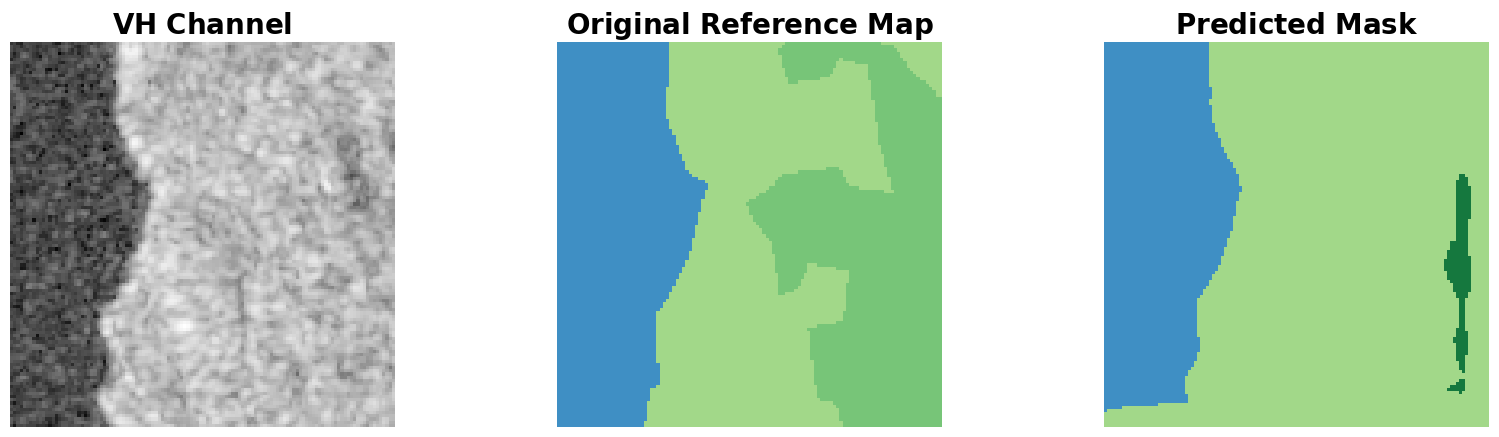

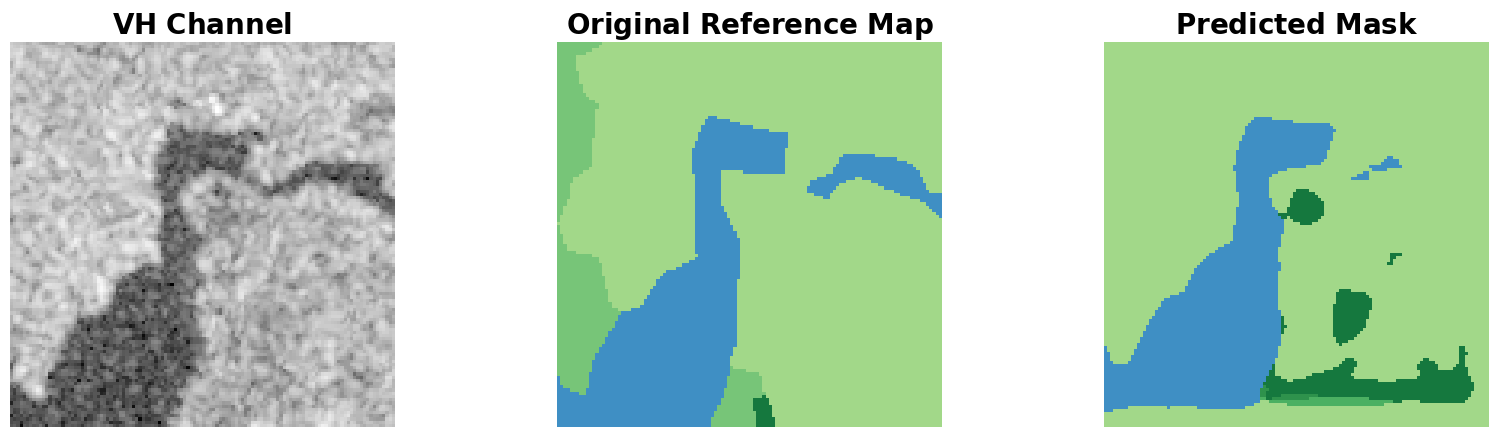

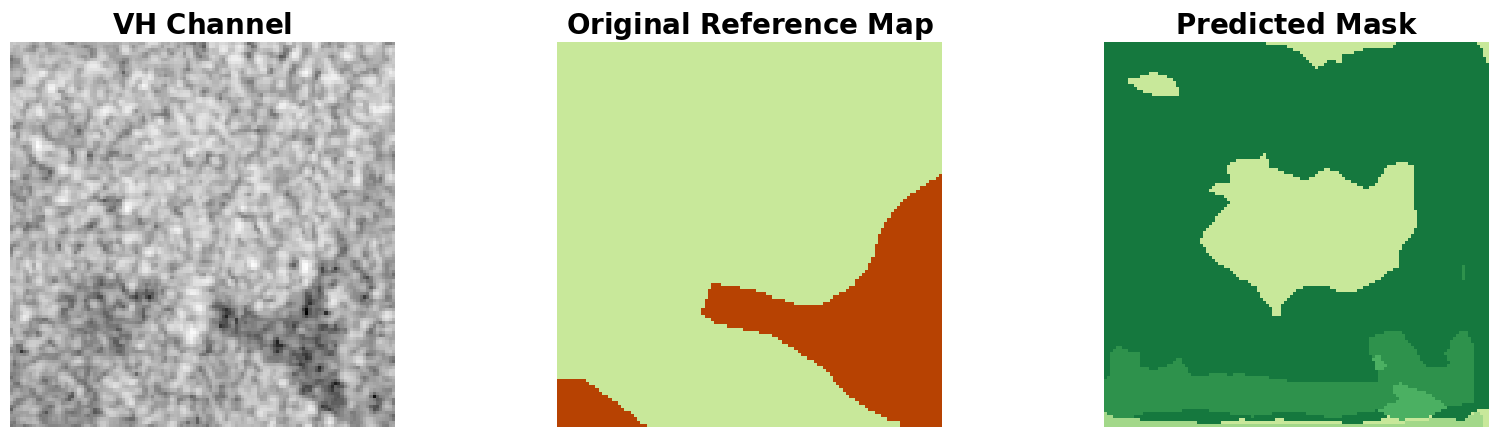

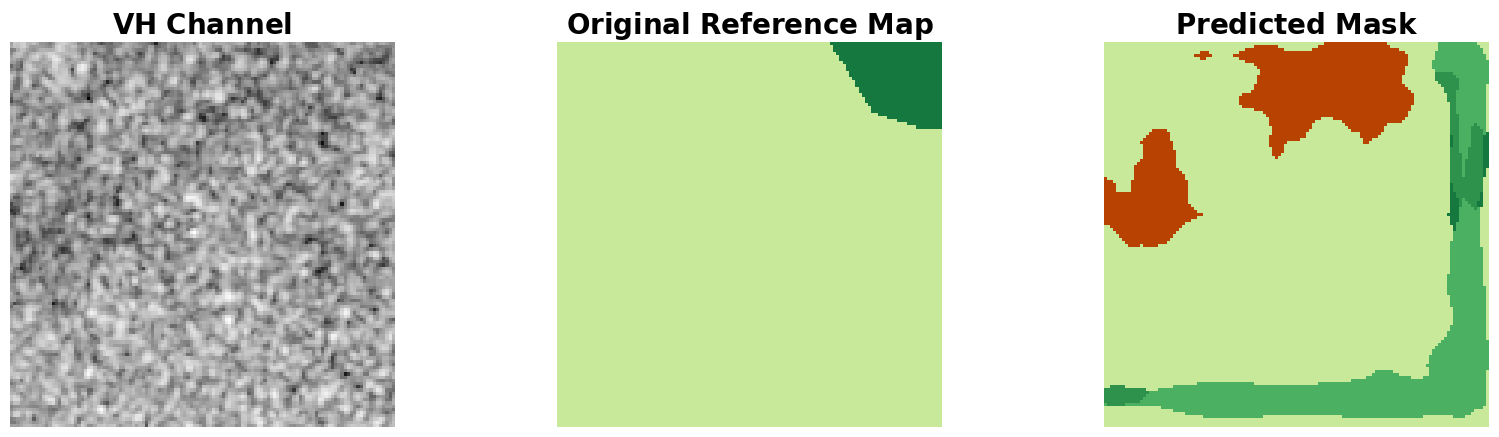

In [9]:
# Good
display_image_reference_inference(model_activations, lmdb_path, "S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62", "S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_55_62_reference_map", img_size= 128)
display_image_reference_inference(model_activations, lmdb_path, "S1A_IW_GRDH_1SDV_20180526T045642_34WFU_35_21", "S2A_MSIL2A_20180526T100031_N9999_R122_T34WFU_35_21_reference_map", img_size= 128)

# Bad ? 
display_image_reference_inference(model_activations, lmdb_path, "S1B_IW_GRDH_1SDV_20180515T063421_29SNC_25_84", "S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_25_84_reference_map", img_size= 128)
display_image_reference_inference(model_activations, lmdb_path, "S1B_IW_GRDH_1SDV_20180515T063421_29SNC_44_47", "S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_44_47_reference_map", img_size= 128)

In [10]:
test_loss, test_iou, test_f1 = calculate_scores(model_activations, test_loader, device, num_classes=20)

Calculating scores: 100%|██████████| 7490/7490 [08:12<00:00, 15.21it/s]

Test Loss: 3.555260316424758, Test IoU: 0.45340195837342373, Test F1: 0.5909117406888185
